In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

base_dir = Path().resolve().parent
sys.path.append(str(base_dir))

from utils.load_results import load_evaluations, load_shap_values
from src.sector.sector_comparison import (
    plot_sector_heatmap,
    plot_feature_across_sectors,
    plot_sector_clustering,
    plot_directional_impact_by_sector,
    print_sector_summary,
)

RF_MODEL_DIR = str(base_dir / "models_sectors/rf")
RIDGE_MODEL_DIR = str(base_dir / "models_sectors/ridge")
RF_MODEL_PARAMS = str(base_dir / "params/rf")
RIDGE_MODEL_PARAMS = str(base_dir / "params/ridge")

In [2]:
ridge_results   = load_evaluations(RIDGE_MODEL_DIR)
ridge_shap_data = load_shap_values(RIDGE_MODEL_DIR)

rf_results   = load_evaluations(RF_MODEL_DIR)
rf_shap_data = load_shap_values(RF_MODEL_DIR)



Loaded 5 evaluations: ['energy', 'finance', 'healthcare', 'industrial', 'tech']
Loaded 5 SHAP files: ['energy', 'finance', 'healthcare', 'industrial', 'tech']
Loaded 5 evaluations: ['energy', 'finance', 'healthcare', 'industrial', 'tech']
Loaded 5 SHAP files: ['energy', 'finance', 'healthcare', 'industrial', 'tech']


<Figure size 1200x500 with 0 Axes>

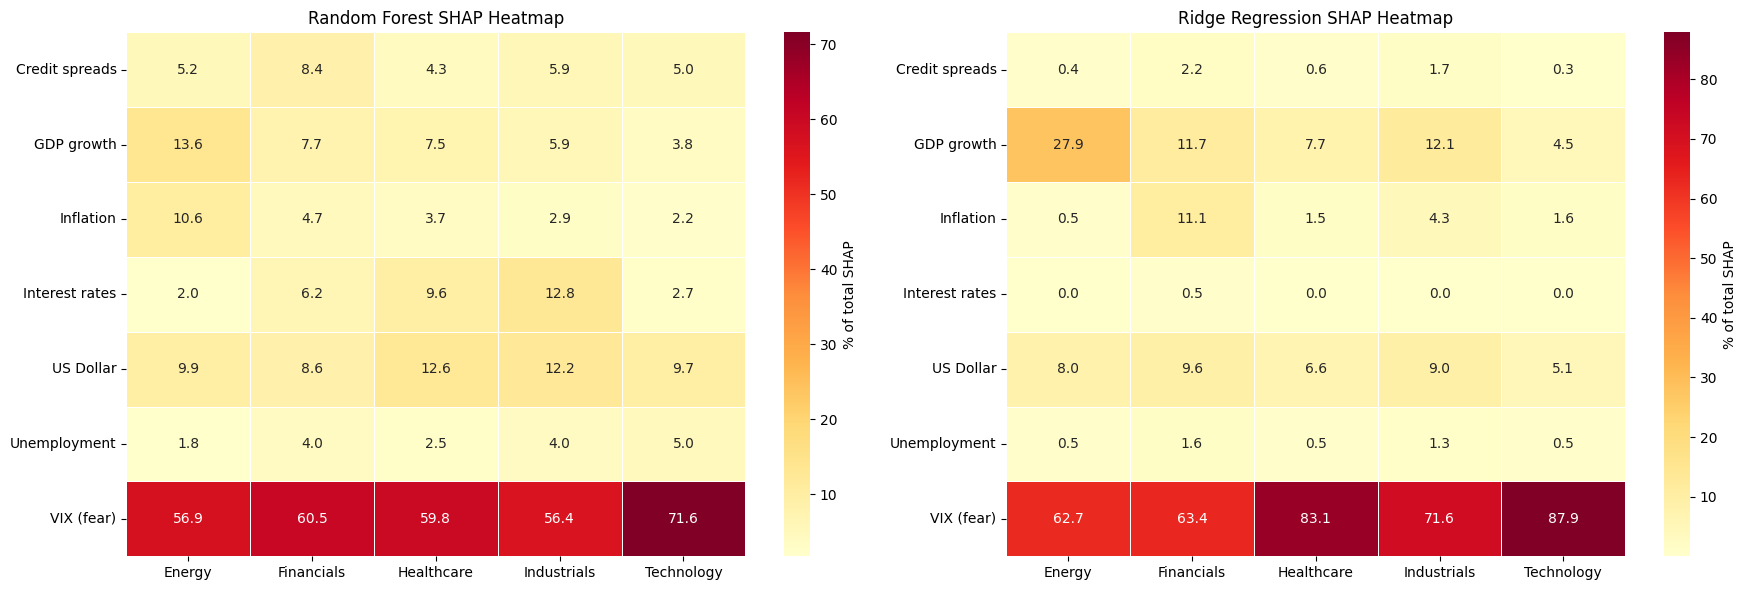

In [ ]:
plt.figure(figsize=(12, 5))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plot_sector_heatmap(rf_shap_data, ax=axes[0])
axes[0].set_title("Random Forest SHAP Heatmap")

plot_sector_heatmap(ridge_shap_data, ax=axes[1])
axes[1].set_title("Ridge Regression SHAP Heatmap")

plt.tight_layout()
plt.show()

In [6]:
print_sector_summary(rf_shap_data)
print_sector_summary(ridge_shap_data)



  TOP MACRO DRIVER PER SECTOR

  Sector               Top feature                 Importance 2nd feature              
  -----------------------------------------------------------------
  Energy               VIX (fear)                      56.9%  GDP growth               
  Financials           VIX (fear)                      60.5%  US Dollar                
  Healthcare           VIX (fear)                      59.8%  US Dollar                
  Industrials          VIX (fear)                      56.4%  Interest rates           
  Technology           VIX (fear)                      71.6%  US Dollar                

  TOP MACRO DRIVER PER SECTOR

  Sector               Top feature                 Importance 2nd feature              
  -----------------------------------------------------------------
  Energy               VIX (fear)                      62.7%  GDP growth               
  Financials           VIX (fear)                      63.4%  GDP growth               
  Health

In [ ]:

# plot_sector_heatmap(shap_data)
# print_sector_summary(shap_data)
# plot_directional_impact_by_sector(shap_data)
# plot_feature_across_sectors(shap_data, "CPI_Change_lag1")
# plot_feature_across_sectors(shap_data, "Rate_Change")
# plot_sector_clustering(shap_data)

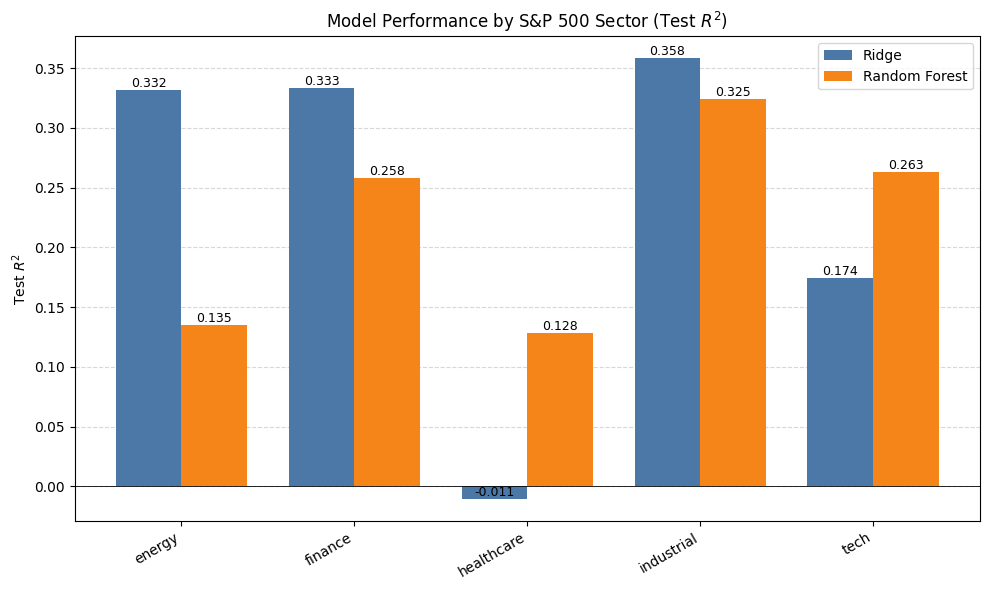

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Collect sectors (union, preserving order) and R² values
sectors = sorted(set(ridge_results) | set(rf_results))

ridge_r2 = [ridge_results[s]["test_metrics"]["r2"] if s in ridge_results else np.nan
            for s in sectors]
rf_r2    = [rf_results[s]["test_metrics"]["r2"]    if s in rf_results    else np.nan
            for s in sectors]

# Grouped bar chart
x = np.arange(len(sectors))
width = 0.38

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, ridge_r2, width, label="Ridge", color="#4C78A8")
bars2 = ax.bar(x + width/2, rf_r2,    width, label="Random Forest", color="#F58518")

# Value labels on top of bars
for bars in (bars1, bars2):
    for b in bars:
        h = b.get_height()
        if not np.isnan(h):
            ax.text(b.get_x() + b.get_width()/2, h,
                    f"{h:.3f}", ha="center", va="bottom", fontsize=9)

ax.axhline(0, color="black", linewidth=0.6)
ax.set_xticks(x)
ax.set_xticklabels(sectors, rotation=30, ha="right")
ax.set_ylabel("Test $R^2$")
ax.set_title("Model Performance by S&P 500 Sector (Test $R^2$)")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()